## Load Feature Dataset

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/time_series_features.csv")

df["appointmentday"] = pd.to_datetime(df["appointmentday"])
df.set_index("appointmentday", inplace=True)

df.head()

,patient_count,day_of_week,target,lag_1,lag_3,lag_7,rolling_mean_3,rolling_std_3,month,day_of_month,is_weekend
appointmentday,,,,,,,,,,,
2016-05-06,3084.0,4,0.0,3466.0,3425.0,2602.0,3248.333333,196.505301,5,6,0
2016-05-07,0.0,5,0.0,3084.0,3195.0,0.0,2183.333333,1900.444509,5,7,1
2016-05-08,0.0,6,3501.0,0.0,3466.0,0.0,1028.000000,1780.548230,5,8,1
2016-05-09,3501.0,0,3316.0,0.0,3084.0,3515.0,1167.000000,2021.303292,5,9,0
2016-05-10,3316.0,1,3589.0,3501.0,0.0,3425.0,2272.333333,1970.071149,5,10,0


## Define Features and Target

In [2]:
X = df.drop(columns=["target"])
y = df["target"]

## Time-Based Train/Test Split (CRITICAL)

In [3]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

## Baseline Model (Very Important)

In [4]:
# Use previous data as prediction
y_pred_baseline = X_test["lag_1"]

## Evaluation Function

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print(f"{name}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print("-" * 30)

## Evaluate the Baseline model

In [6]:
evaluate(y_test, y_pred_baseline, "Baseline (Lag-1)")

Baseline (Lag-1)
MAE: 2099.57
RMSE: 2693.64
------------------------------


Interpreting the Baseline (Lag-1)  

Baseline (Lag-1): using the previous value as the prediction  

It shows:   
Large errors (~2k units)  
High variability dataset  
Weak predictive power

## Model 1: Linear Regression

In [7]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

evaluate(y_test, y_pred_lr, "Linear Regression")

Linear Regression
MAE: 1085.16
RMSE: 1311.87
------------------------------


Interpretation  
Lower error overall  
More stable predictions  
Capturing real relationships in data  
There’s a linear relationship  
Features actually explain the target  
Your Linear Regression model is significantly better, cutting error roughly in half and producing more stable predictions.

## Model 2: Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Base model
rf = RandomForestRegressor(random_state=42)

# Parameter grid to search
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Grid search
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring="neg_mean_squared_error", n_jobs=-1, verbose=1)

# Fit on training data ONLY
grid_search.fit(X_train, y_train)

# Best model
best_rf = grid_search.best_estimator_

print("Best params:", grid_search.best_params_)

y_pred_rf = best_rf.predict(X_test)
evaluate(y_test, y_pred_rf, "Random Forest (Tuned)")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Random Forest (Tuned)
MAE: 897.47
RMSE: 1214.33
------------------------------


Interpretation  
Improvement Over Linear Regression
MAE improved by ~22%
RMSE improved by ~10%

This tells us:

The data likely contains non-linear patterns that Linear Regression couldn’t capture.  
Some larger errors still exist
But not extreme (gap is reasonable)
Model is fairly stable   

Random Forest:

Captures non-linear relationships  
Handles interactions between features  
Reduces overfitting via averaging multiple trees  

Random Forest model is currently the best-performing model, reducing error significantly and capturing patterns that simpler models missed.

## Model 3: XGBoost

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

# Base model
xgb = XGBRegressor(random_state=42, objective="reg:squarederror", n_jobs=-1)

# Parameter grid
param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 4, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=5, scoring="neg_mean_squared_error", n_jobs=-1, verbose=1)

# Fit ONLY on training data
grid_search.fit(X_train, y_train)

# Best model
best_xgb = grid_search.best_estimator_

print("Best params:", grid_search.best_params_)

y_pred_xgb = best_xgb.predict(X_test)
evaluate(y_test, y_pred_xgb, "XGBoost (Tuned)")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
XGBoost (Tuned)
MAE: 770.16
RMSE: 1176.31
------------------------------


Interpretation  
XGBoost performs better than the linear model implying:
 - Existence of non-linear relations in the dataset which the model captures
 - The model is failry stable
 - This is the best performing model

## Compare Predictions Visually

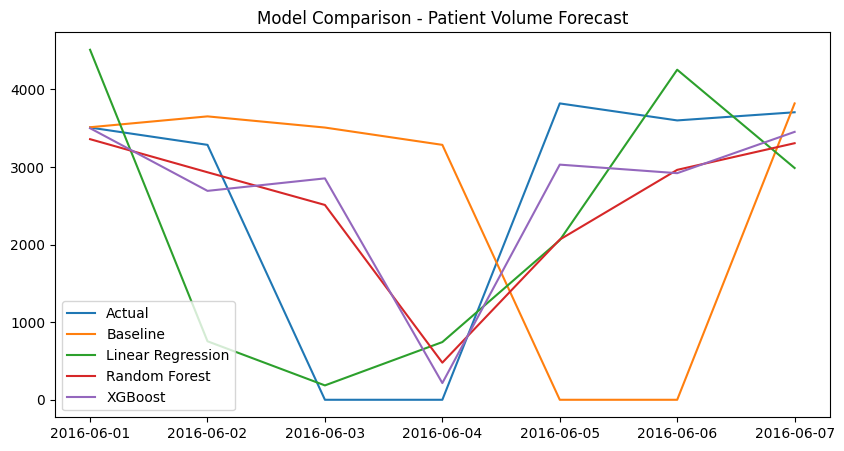

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred_baseline, label="Baseline")
plt.plot(y_test.index, y_pred_lr, label="Linear Regression")
plt.plot(y_test.index, y_pred_rf, label="Random Forest")
plt.plot(y_test.index, y_pred_xgb, label="XGBoost")

plt.legend()
plt.title("Model Comparison - Patient Volume Forecast")
plt.show()

In [18]:
plt.savefig("../outputs/figures/model_comparison.png")

<Figure size 640x480 with 0 Axes>

## Feature Importance

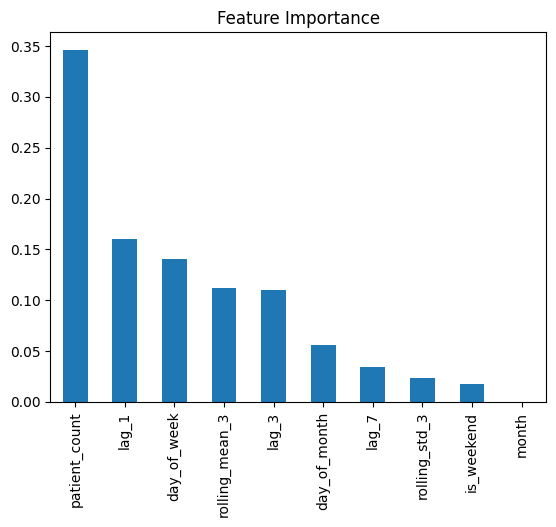

In [19]:
import pandas as pd

importance = pd.Series(best_xgb.feature_importances_, index=X.columns).sort_values(ascending=False)

importance.plot(kind="bar")
plt.title("Feature Importance")
plt.show()

In [20]:
plt.savefig("../outputs/figures/feature_importance_ts.png")

<Figure size 640x480 with 0 Axes>

## Intepretation
**Key Findings**

- Lag features (especially lag_1) are the strongest predictors
- Short-term temporal patterns dominate forecasting performance
- Random forest is the best perfoming model

## Model Saving

In [21]:
import joblib

joblib.dump(best_xgb, "../outputs/models/xgboost_model.pkl")

['../outputs/models/xgboost_model.pkl']